   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.2 MB/s eta 0:00:00
Raw shape: (60889, 6)
Dropped 32 rows with missing Review_text
Clean shape: (60773, 8)


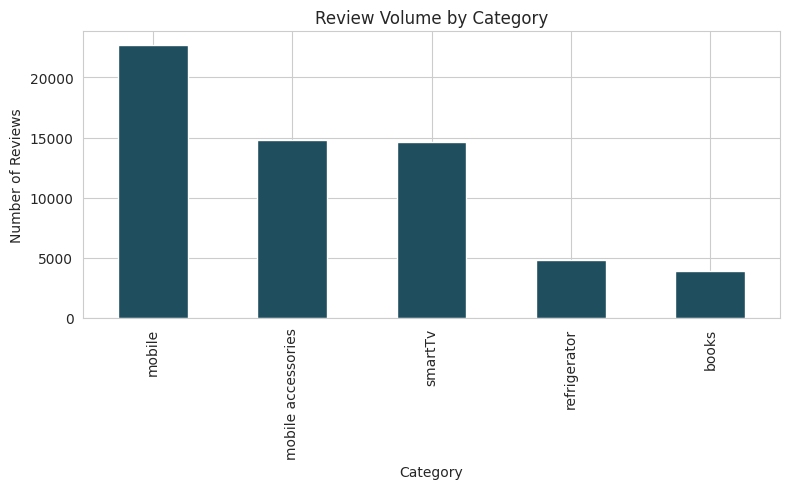

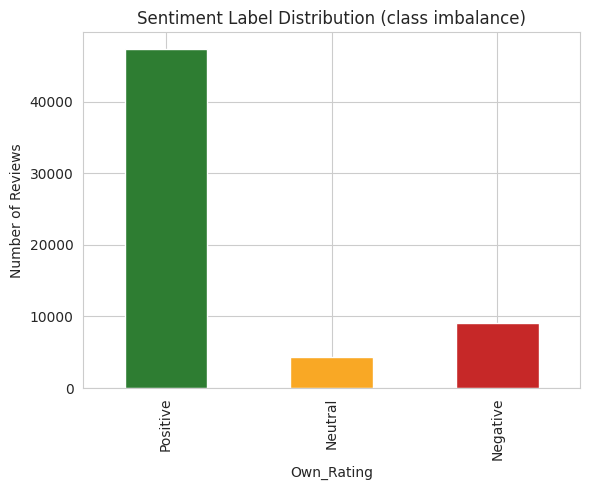

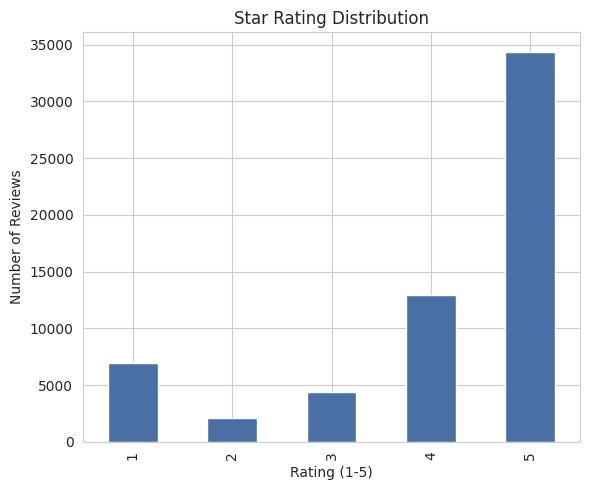

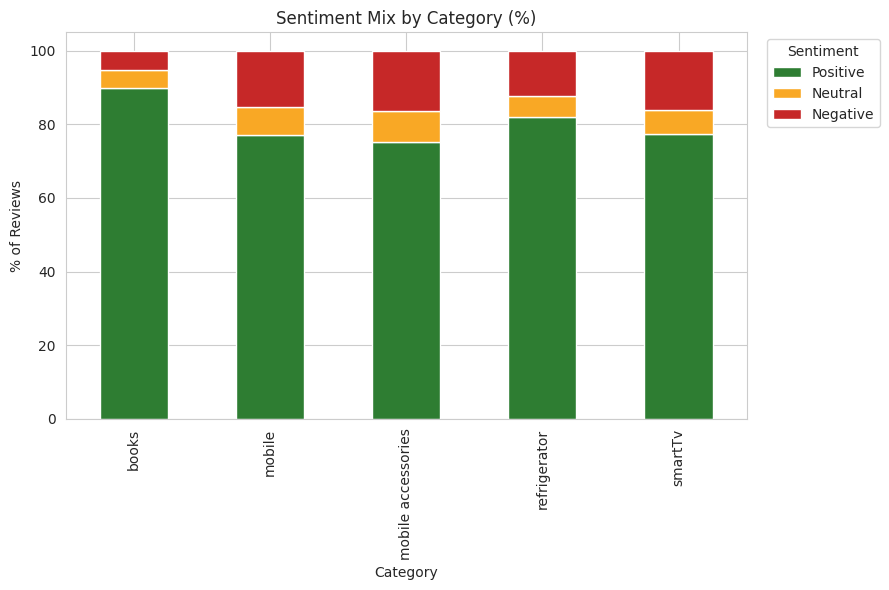

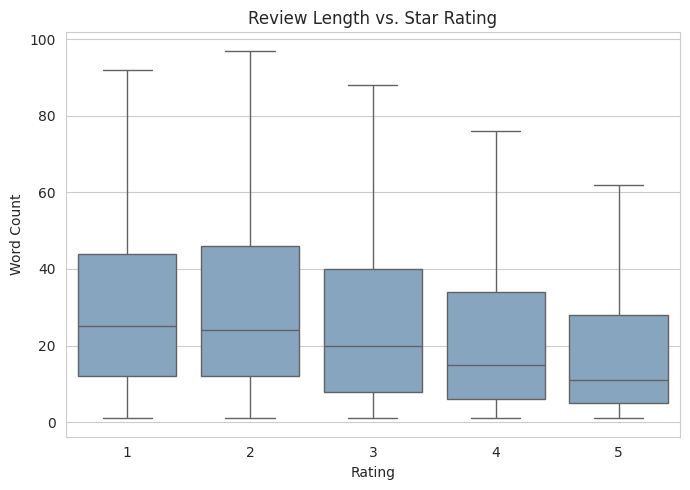


--- EDA Summary ---
Reviews per category:
 Category
mobile                22704
mobile accessories    14798
smartTv               14593
refrigerator           4783
books                  3895
Name: count, dtype: int64

Sentiment balance:
 Own_Rating
Positive    77.9
Negative    14.9
Neutral      7.2
Name: proportion, dtype: float64

Negative-review rate by category (%):
Category
mobile accessories    16.5
smartTv               16.2
mobile                15.4
refrigerator          12.3
books                  5.3
Name: Negative, dtype: float64

--- Model Comparison ---

Logistic Regression:
  Accuracy:  0.800
  Precision: 0.864
  Recall:    0.800
  F1-score:  0.825
              precision    recall  f1-score   support

    Negative       0.70      0.77      0.73      1816
     Neutral       0.21      0.44      0.28       872
    Positive       0.96      0.84      0.89      9467

    accuracy                           0.80     12155
   macro avg       0.62      0.68      0.64     12155
w

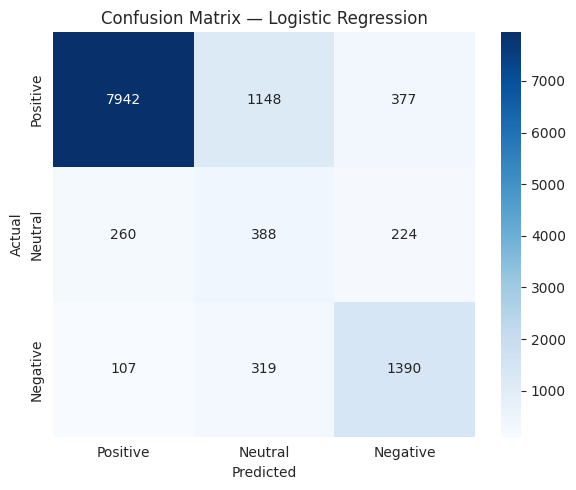


--- Top words per sentiment class (Logistic Regression coefficients) ---

Negative: worst, star, don buy, waste, pathetic, worst phone, defective, poor, cheating, return, refund, disappointed, zero, bad, faulty

Neutral: limited, awesome awesome, average, mrp, money better, glitch, edit, delicate, excellent best, don expect, okay, camera superb, product ok, ok product, phone charging

Positive: awesome, amazing, best, excellent, superb, love, great, perfect, fantastic, wonderful, loved, budget, beast, nice product, value money


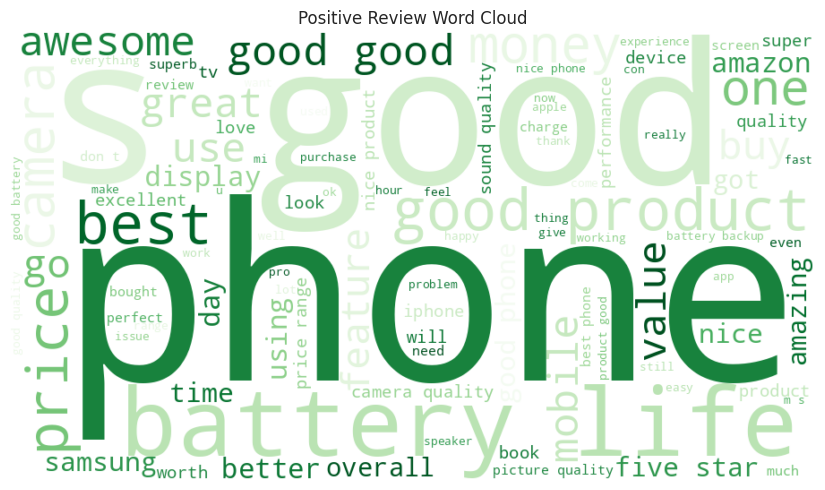

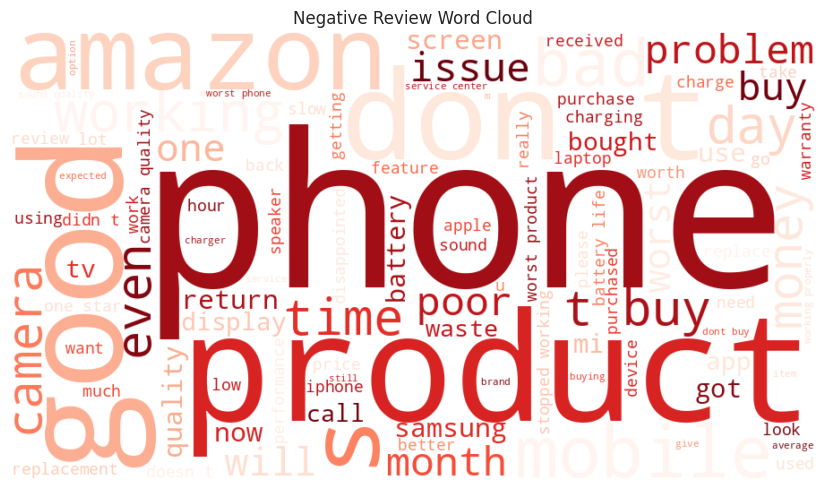


VADER vs Own_Rating agreement: 82.6%

Disagreement rate by category:
Category
mobile accessories    18.9
mobile                17.6
smartTv               17.3
books                 15.5
refrigerator          14.0
dtype: float64

All charts saved to ./output_charts/
Done.


/tmp/ipykernel_1681/3672718055.py:228: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  disagreement_by_cat = df.groupby("Category").apply(


In [3]:
# ---------------------------------------------------------------------------
# SETUP (Colab only — installs packages not preinstalled; skip if running
# locally with these already installed)
# ---------------------------------------------------------------------------
!pip install wordcloud vaderSentiment -q

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
CSV_PATH = "/content/Amazon Review Data Web Scrapping - Amazon Review Data Web Scrapping (1).csv"
OUTPUT_DIR = "output_charts"
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# STEP 1: LOAD & CLEAN
# ---------------------------------------------------------------------------
def load_and_clean(path):
    df = pd.read_csv(path)
    print(f"Raw shape: {df.shape}")

    before = len(df)
    df = df.dropna(subset=["Review_text"]).copy()
    print(f"Dropped {before - len(df)} rows with missing Review_text")

    df["Review_Header"] = df["Review_Header"].fillna("")
    df["full_text"] = (df["Review_Header"] + " " + df["Review_text"]).str.strip()

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"http\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    df["clean_text"] = df["full_text"].apply(clean_text)
    df = df[df["clean_text"].str.len() > 0].copy()

    df["Category"] = df["Category"].str.strip()
    df["Own_Rating"] = df["Own_Rating"].str.strip()

    print(f"Clean shape: {df.shape}")
    return df


# ---------------------------------------------------------------------------
# STEP 2: EDA (each chart is saved AND shown inline via plt.show())
# ---------------------------------------------------------------------------
def run_eda(df):
    order = ["Positive", "Neutral", "Negative"]
    colors = ["#2E7D32", "#F9A825", "#C62828"]

    # Category volume
    plt.figure(figsize=(8, 5))
    df["Category"].value_counts().plot(kind="bar", color="#1F4E5F")
    plt.title("Review Volume by Category")
    plt.ylabel("Number of Reviews")
    plt.xlabel("Category")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/01_category_volume.png", dpi=150)
    plt.show()

    # Sentiment distribution (class imbalance check)
    plt.figure(figsize=(6, 5))
    counts = df["Own_Rating"].value_counts().reindex(order)
    counts.plot(kind="bar", color=colors)
    plt.title("Sentiment Label Distribution (class imbalance)")
    plt.ylabel("Number of Reviews")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/02_sentiment_distribution.png", dpi=150)
    plt.show()

    # Rating distribution
    plt.figure(figsize=(6, 5))
    df["Rating"].value_counts().sort_index().plot(kind="bar", color="#4A6FA5")
    plt.title("Star Rating Distribution")
    plt.xlabel("Rating (1-5)")
    plt.ylabel("Number of Reviews")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/03_rating_distribution.png", dpi=150)
    plt.show()

    # Sentiment by category (stacked)
    cross = pd.crosstab(df["Category"], df["Own_Rating"], normalize="index") * 100
    cross = cross[order]
    cross.plot(kind="bar", stacked=True, color=colors, figsize=(9, 6))
    plt.title("Sentiment Mix by Category (%)")
    plt.ylabel("% of Reviews")
    plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/04_sentiment_by_category.png", dpi=150)
    plt.show()

    # Review length vs rating
    df["review_len"] = df["clean_text"].str.split().apply(len)
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x="Rating", y="review_len", showfliers=False, color="#7FA6C9")
    plt.title("Review Length vs. Star Rating")
    plt.ylabel("Word Count")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/05_length_vs_rating.png", dpi=150)
    plt.show()

    print("\n--- EDA Summary ---")
    print("Reviews per category:\n", df["Category"].value_counts())
    print("\nSentiment balance:\n", df["Own_Rating"].value_counts(normalize=True).round(3) * 100)
    print("\nNegative-review rate by category (%):")
    print((cross["Negative"]).sort_values(ascending=False).round(1))


# ---------------------------------------------------------------------------
# STEP 3 & 4: TF-IDF + CLASSIFICATION
# ---------------------------------------------------------------------------
def train_and_evaluate(df):
    X = df["clean_text"]
    y = df["Own_Rating"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    vectorizer = TfidfVectorizer(
        max_features=8000, ngram_range=(1, 2), min_df=3, stop_words="english"
    )
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    results = {}

    log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
    log_reg.fit(X_train_tfidf, y_train)
    y_pred_lr = log_reg.predict(X_test_tfidf)
    results["Logistic Regression"] = y_pred_lr

    nb = MultinomialNB()
    nb.fit(X_train_tfidf, y_train)
    y_pred_nb = nb.predict(X_test_tfidf)
    results["Naive Bayes"] = y_pred_nb

    print("\n--- Model Comparison ---")
    for name, y_pred in results.items():
        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="weighted", zero_division=0
        )
        print(f"\n{name}:")
        print(f"  Accuracy:  {acc:.3f}")
        print(f"  Precision: {precision:.3f}")
        print(f"  Recall:    {recall:.3f}")
        print(f"  F1-score:  {f1:.3f}")
        print(classification_report(y_test, y_pred, zero_division=0))

    labels = ["Positive", "Neutral", "Negative"]
    cm = confusion_matrix(y_test, y_pred_lr, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix — Logistic Regression")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/06_confusion_matrix.png", dpi=150)
    plt.show()

    feature_names = np.array(vectorizer.get_feature_names_out())
    print("\n--- Top words per sentiment class (Logistic Regression coefficients) ---")
    for i, cls in enumerate(log_reg.classes_):
        top_idx = np.argsort(log_reg.coef_[i])[-15:][::-1]
        print(f"\n{cls}: {', '.join(feature_names[top_idx])}")

    return log_reg, vectorizer, y_test, y_pred_lr


# ---------------------------------------------------------------------------
# STEP 5: WORD CLOUDS — positive vs negative reviews
# ---------------------------------------------------------------------------
def make_wordclouds(df):
    for sentiment, cmap in [("Positive", "Greens"), ("Negative", "Reds")]:
        text = " ".join(df.loc[df["Own_Rating"] == sentiment, "clean_text"])
        wc = WordCloud(width=900, height=500, background_color="white",
                        colormap=cmap, max_words=100).generate(text)
        plt.figure(figsize=(9, 5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{sentiment} Review Word Cloud")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/wordcloud_{sentiment.lower()}.png", dpi=150)
        plt.show()


# ---------------------------------------------------------------------------
# STEP 6: VADER lexicon-based sentiment vs. the dataset's own labels
# ---------------------------------------------------------------------------
def run_vader_comparison(df):
    analyzer = SentimentIntensityAnalyzer()

    def vader_label(text):
        score = analyzer.polarity_scores(text)["compound"]
        if score >= 0.05:
            return "Positive"
        elif score <= -0.05:
            return "Negative"
        return "Neutral"

    df["vader_sentiment"] = df["clean_text"].apply(vader_label)

    agreement = (df["vader_sentiment"] == df["Own_Rating"]).mean()
    print(f"\nVADER vs Own_Rating agreement: {agreement:.1%}")

    disagreement_by_cat = df.groupby("Category").apply(
        lambda g: (g["vader_sentiment"] != g["Own_Rating"]).mean()
    ).sort_values(ascending=False)
    print("\nDisagreement rate by category:")
    print((disagreement_by_cat * 100).round(1))

    return df


# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------
df = load_and_clean(CSV_PATH)
run_eda(df)
model, vectorizer, y_test, y_pred = train_and_evaluate(df)
make_wordclouds(df)
df = run_vader_comparison(df)

print(f"\nAll charts saved to ./{OUTPUT_DIR}/")
print("Done.")